In [9]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [1]:
# parameter Shor
N = 111      # angka yang ingin difaktorkan
a = 2       # bilangan coprime dengan N

n_count = 8   # jumlah qubit register atas
shots = 1024  # jumlah pengukuran

In [2]:
def qft_dagger(circuit, n):

    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)

    for j in range(n):
        for m in range(j):
            circuit.cp(-np.pi/(2**(j-m)), m, j)

        circuit.h(j)

In [3]:
def approx_qft_dagger(circuit, n, kmax):

    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)

    for j in range(n):
        for m in range(j):

            if (j-m) <= kmax:
                circuit.cp(-np.pi/(2**(j-m)), m, j)

        circuit.h(j)

In [4]:
def build_qpe(n_count, approximate=False):
    qc = QuantumCircuit(n_count+1, n_count)

    #Superposition
    for q in range(n_count):
        qc.h(q)
    
    #Eigenstate
    qc.x(n_count)

    #Controlled operation
    for q in range(n_count):
        qc.cp(np.pi/2**q, q, n_count)
    
    # inverse QFT
    if approx_qft_dagger:
        kmax = int(np.log2(n_count))
        approx_qft_dagger(qc, n_count, kmax)
    else:
        qft_dagger(qc, n_count)

    #Measurement
    for i in range(n_count):
        qc.measure(i,i)

    return qc




In [5]:
def run_simulation(qc):
    sim = AerSimulator()
    shots = 1024

    result = sim.run(qc,shots=shots).result()
    counts = result.get_counts()

    states=[]
    probs=[]

    for k,v in counts.items():
        states.append(int(k,2))
        probs.append(v/shots)

    return states,probs

In [6]:
def theoretical_spectrum(n_count,r):
    x=np.arange(2**n_count)
    prob=np.zeros(len(x))

    for s in range(r):
        theta=s/r
        peak=int(theta*(2**n_count))
        prob[peak]+=1/r

    return x,prob

In [7]:
def plot_case(ax,title,n_count,r,approx):

    qc=build_qpe(n_count,approx)
    states,probs=run_simulation(qc)

    x,prob_theory=theoretical_spectrum(n_count,r)

    ax.bar(states,probs,width=0.8,label="Simulated")
    ax.plot(x,prob_theory,'r',label="Theoretical")

    ax.set_title(title)
    ax.set_xlabel("State")
    ax.set_ylabel("Frequency")

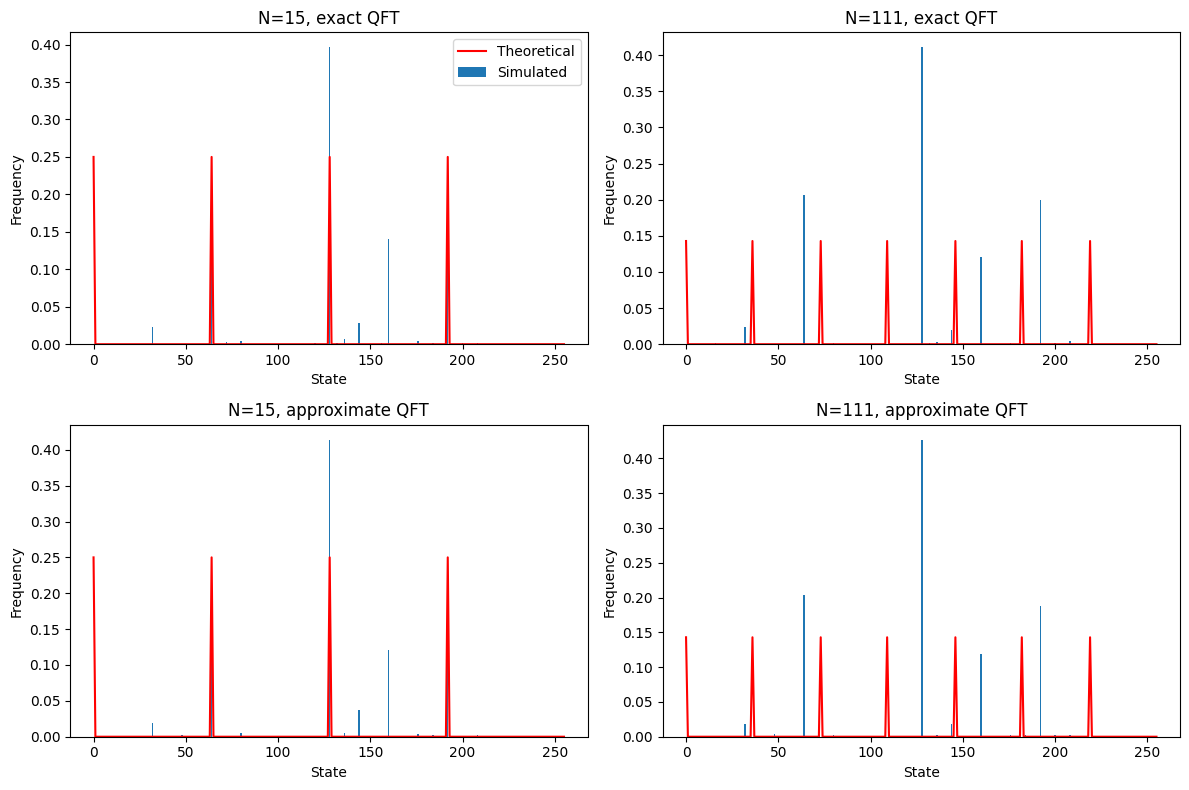

In [10]:
fig,axs=plt.subplots(2,2,figsize=(12,8))

plot_case(axs[0,0],"N=15, exact QFT",8,4,False)
plot_case(axs[0,1],"N=111, exact QFT",8,7,False)

plot_case(axs[1,0],"N=15, approximate QFT",8,4,True)
plot_case(axs[1,1],"N=111, approximate QFT",8,7,True)

axs[0,0].legend()

plt.tight_layout()
plt.show()